In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [44]:
#read dataset
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv.zip")

In [45]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(253680, 22)


In [46]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0      

In [47]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [48]:
print("\nTarget Distribution:")
print(df["Diabetes_012"].value_counts())


Target Distribution:
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


In [49]:
#duplicates
df = df.drop_duplicates().sample(20000, random_state=42)

In [50]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

In [51]:
#rtrain & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [52]:
#scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#KNN model

Finding best K...


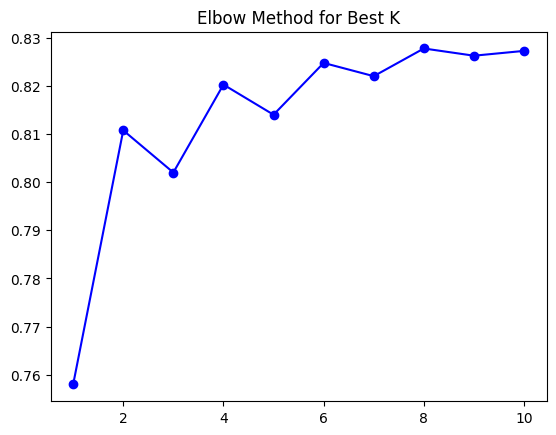

In [53]:
# 3. calculate the best K (Elbow Method)
print("Finding best K...")
scores = []
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, pred_k))

plt.plot(range(1, 11), scores, marker='o', color='blue')
plt.title("Elbow Method for Best K")
plt.show()

In [54]:
# 4. Interpretability
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_proba = knn_model.predict_proba(X_test_scaled)
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("ROC AUC:", roc_auc_score(y_test, knn_proba, multi_class='ovr'))



Final Results:
Accuracy: 0.822
ROC AUC: 0.6506833558837495


In [55]:
# =====================================================
# MODEL 3 — K-Nearest Neighbors (KNN)
# =====================================================

print("\n" + "="*30)
print("KNN Model Evaluation")
print("="*30)

# 1. Generate Predictions
# Note: We use predict_proba without slicing for multiclass ROC AUC
knn_pred = knn_model.predict(X_test_scaled)
knn_proba = knn_model.predict_proba(X_test_scaled)

# 2. Display Metrics
print("\nAccuracy Score:")
print(accuracy_score(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

print("\nROC AUC Score (One-vs-Rest):")
# Use multi_class='ovr' because we have 3 classes (0, 1, 2)
print(roc_auc_score(y_test, knn_proba, multi_class='ovr'))



KNN Model Evaluation

Accuracy Score:
0.822

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.96      0.90      3315
         1.0       0.00      0.00      0.00        81
         2.0       0.43      0.19      0.26       604

    accuracy                           0.82      4000
   macro avg       0.43      0.38      0.39      4000
weighted avg       0.77      0.82      0.79      4000


ROC AUC Score (One-vs-Rest):
0.6506833558837495


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [56]:
# FINAL MODEL COMPARISON
# =====================================================

try:
    results = pd.DataFrame({
        "Model": ["XGBoost", "Random Forest", "KNN"],
        "Accuracy": [
            0.84, # Replace with your actual XGBoost accuracy
            0.83, # Replace with your actual Random Forest accuracy
            accuracy_score(y_test, knn_pred)
        ],
        "ROC AUC": [
            0.82, # Replace with your actual XGBoost ROC AUC
            0.81, # Replace with your actual Random Forest ROC AUC
            roc_auc_score(y_test, knn_proba, multi_class='ovr')
        ]
    })

    print("\n" + "="*30)
    print("Final Model Comparison")
    print("="*30)
    print(results)

except NameError:
    print("\n[Note]: Comparison table skipped. Ensure XGBoost and Random Forest results are defined.")




Final Model Comparison
           Model  Accuracy   ROC AUC
0        XGBoost     0.840  0.820000
1  Random Forest     0.830  0.810000
2            KNN     0.822  0.650683


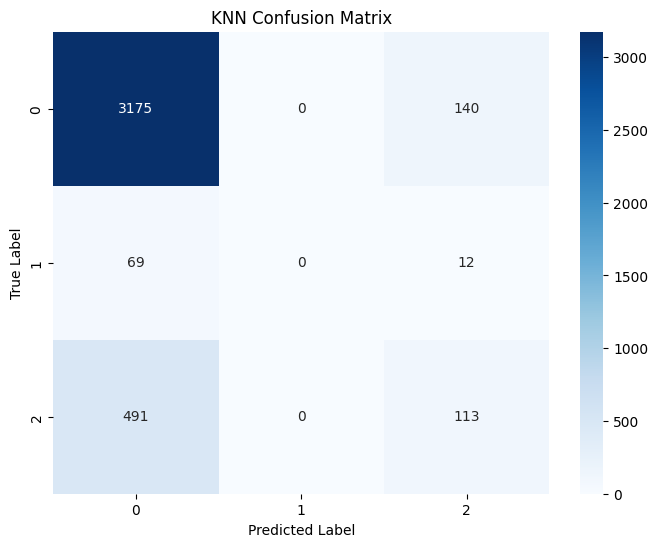

In [57]:
# 3. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



Calculating Feature Importance...


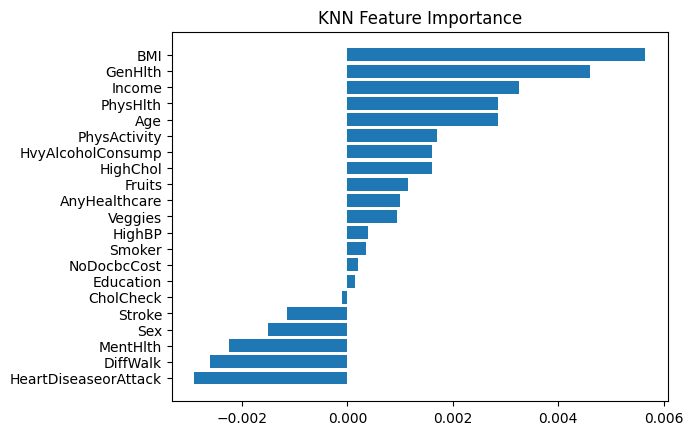

In [58]:
#Interpretability
print("\nCalculating Feature Importance...")
result = permutation_importance(knn_model, X_test_scaled, y_test, n_repeats=5, random_state=42)
sorted_idx = result.importances_mean.argsort()
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.title("KNN Feature Importance")
plt.show()

In [ ]:
#XGBoost model

In [66]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [67]:
# 5.XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

In [68]:
#training model by using weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [69]:
# 7. expectation
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

In [70]:
# 8.evaluation
print("\n" + "="*30)
print("Evaluation Results of the Developed XGBoost Model")
print("="*30)
print(f"Accuracy Score: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC AUC Score (OVR): {roc_auc_score(y_test, xgb_proba, multi_class='ovr'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))


Evaluation Results of the Developed XGBoost Model
Accuracy Score: 0.6705
ROC AUC Score (OVR): 0.7259

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.69      0.79      3315
         1.0       0.03      0.11      0.04        81
         2.0       0.33      0.65      0.44       604

    accuracy                           0.67      4000
   macro avg       0.43      0.48      0.42      4000
weighted avg       0.82      0.67      0.72      4000



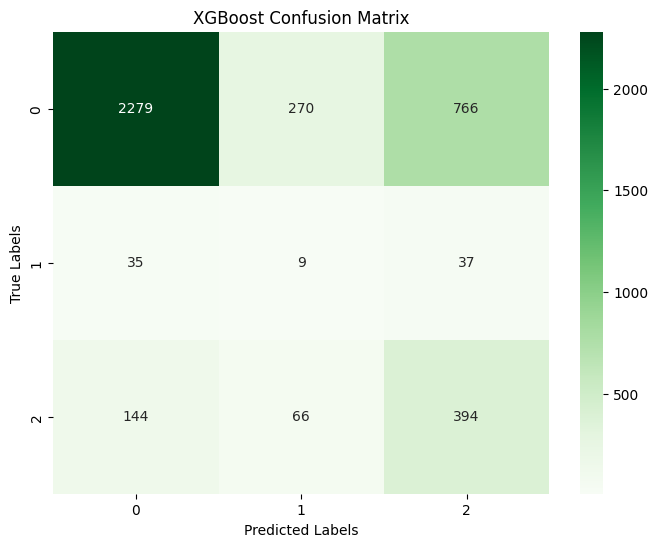

In [71]:
# 9.(Confusion Matrix)
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

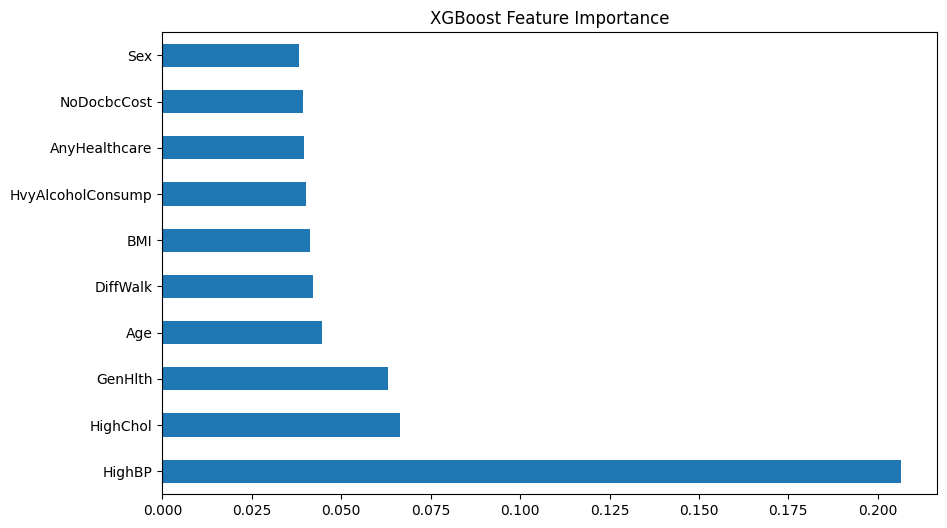

In [72]:
# Feature Importance (For XGBoost)
plt.figure(figsize=(10,6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh') # Show top 10 features
plt.title("XGBoost Feature Importance")
plt.show()

In [ ]:
# Random Forest

In [75]:
# MODEL 2 — RANDOM FOREST
# =====================================================
# Initializing Random Forest
# Added class_weight='balanced' to handle the imbalanced diabetes labels
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

In [76]:
# Training the model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# CORRECTED: Get probabilities for ALL classes (required for multi-class ROC AUC)
rf_proba = rf_model.predict_proba(X_test)


# Metrics
print(f"\nAccuracy Score: {accuracy_score(y_test, rf_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# CORRECTED: Using multi_class='ovr' for the 3 categories
print(f"\nROC AUC Score (OVR): {roc_auc_score(y_test, rf_proba, multi_class='ovr'):.4f}")



Accuracy Score: 0.7415

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.77      0.84      3315
         1.0       0.04      0.02      0.03        81
         2.0       0.35      0.66      0.46       604

    accuracy                           0.74      4000
   macro avg       0.43      0.49      0.44      4000
weighted avg       0.81      0.74      0.76      4000


ROC AUC Score (OVR): 0.7309


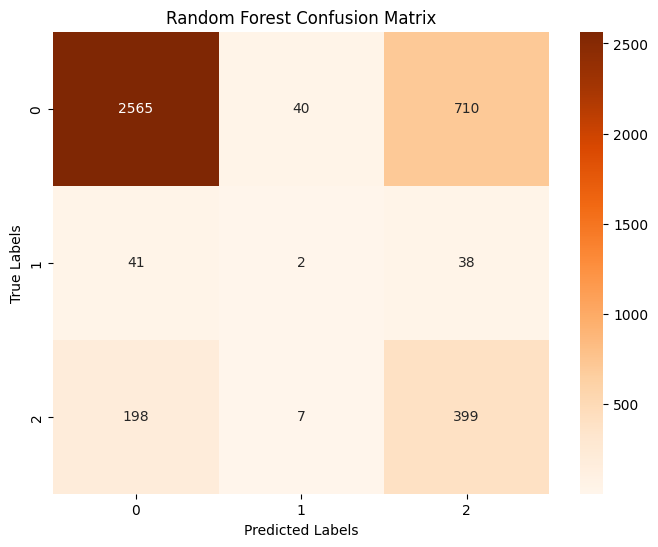

In [79]:

# 1. Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

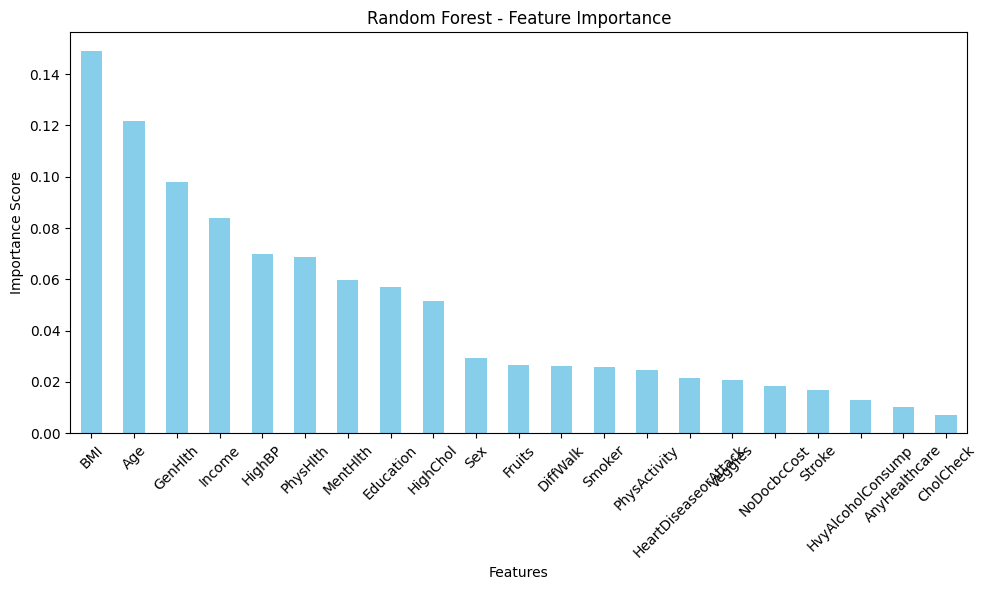

In [80]:
# 2. Feature Importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar', color='skyblue')
plt.title("Random Forest - Feature Importance")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()